# In-Class Problems (Labeled PSet-1)

## Run your local code

Save your changes to the Python files in `pset-1/src/frequent_words/`, then
choose **Run All** in this notebook. After editing your code, save it and
run all cells again to refresh the imports and tests.

This notebook tests the files on your computer, including saved changes
that have not been committed or pushed. No repository URL, commit hash,
or package installation is needed for the tests. The plotting section
requires `matplotlib` in your notebook environment.

Open the notebook from this repository (in `pset-1/` or `grading/`). The
setup cell finds `pset-1/src/` automatically and prints the files it loads.


In [11]:
from pathlib import Path
import importlib
import sys

# Find the local assignment from the notebook's working directory.
for folder in (Path.cwd(), *Path.cwd().parents):
    candidate = folder / "pset-1" / "src"
    if (candidate / "frequent_words" / "__init__.py").is_file():
        PSET_SRC = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        "Cannot find pset-1/src/frequent_words. "
        "Open this notebook from inside your course repository and run it again."
    )

# Prefer these files and discard any previously imported copy of the package.
sys.path[:] = [path for path in sys.path if path != str(PSET_SRC)]
sys.path.insert(0, str(PSET_SRC))
for name in list(sys.modules):
    if name == "frequent_words" or name.startswith("frequent_words."):
        del sys.modules[name]
importlib.invalidate_caches()

pattern_count_module = importlib.import_module("frequent_words.pattern_count")
frequent_words_module = importlib.import_module("frequent_words.frequent_words")

for module in (pattern_count_module, frequent_words_module):
    loaded_file = Path(module.__file__).resolve()
    if not loaded_file.is_relative_to(PSET_SRC):
        raise ImportError(f"Loaded the wrong file: {loaded_file}")
    print(f"Using local file: {loaded_file}")

PatternCount = pattern_count_module.PatternCount
FrequentWords = frequent_words_module.FrequentWords


Using local file: /Users/susiehodson/Desktop/CSC258/stringReps/pset-1/src/frequent_words/pattern_count.py
Using local file: /Users/susiehodson/Desktop/CSC258/stringReps/pset-1/src/frequent_words/frequent_words.py


## Support Code
You don't need to change anything in these cells

In [12]:
class NotImplementedYet(AssertionError):
    pass


def run_function(func, *args, **kwargs):
    try:
        return func(*args, **kwargs)
    except NotImplementedError as e:
        raise NotImplementedYet(
            f"Your {func.__name__} function was found and called successfully! "
            "Now make sure you replace the starter NotImplementedError "
            "with your implementation."
        ) from e

## Algorithm 1: PatternCount 

PatternCount takes two string arguments, text and pattern
It returns an integer representing the number of times pattern appears in text

In [13]:
from frequent_words.pattern_count import PatternCount

In [14]:
# Test: clearly differentiated k-mers
result = run_function(PatternCount, "ATAT", "AT")
assert result == 2, (
    f'Expected 2 for PatternCount("ATAT", "AT"), got {result!r}.'
)

# Test: overlapping windows matter
result = run_function(PatternCount, "GCGCG", "GCG")
assert result == 2, (
    f'Expected 2 overlapping occurrences of "GCG" in "GCGCG", '
    f"got {result!r}."
)

# Test: full text
result = run_function(PatternCount, "ACGT", "ACGT")
assert result == 1, (
    f"A pattern equal to the full text should occur once; got {result!r}."
)

# Test: pattern longer than text
try:
    result = run_function(PatternCount, "ACGT", "AAAAA")
except NotImplementedYet:
    raise
except Exception as e:
    print(
        f"PatternCount raised {type(e).__name__} when the pattern "
        "was longer than the text. This is an acceptable way to handle this case."
    )
else:
    assert result == 0, (
        f"When the pattern is longer than the text, either return 0 "
        f"or raise an error; got {result!r}."
    )


# Test: empty text
try:
    result = run_function(PatternCount, "", "A")
except NotImplementedYet:
    raise
except Exception as e:
    print(
        f"PatternCount raised {type(e).__name__} for empty text. "
        "This is another acceptable way to handle this case."
    )
else:
    assert result == 0, (
        f"An empty text should either return 0 or raise an error; "
        f"got {result!r}."
    )

## Algorithm 2: FrequentWords

In [15]:
from frequent_words.frequent_words import FrequentWords

In [16]:
# Test: one clear winner 
result = run_function(
    FrequentWords,
    "ATAT",
    2
)

assert result == {"AT"}, (
    f'Expected {{"AT"}}, got {result!r}. '
    '"AT" occurs twice in "ATAT".'
)

# Test: one clear winner with overlapping windows
result = run_function(
    FrequentWords,
    "ATATATACGTCGT",
    3
)

assert result == {"ATA"}, (
    f'Expected {{"ATA"}}, got {result!r}. '
    '"ATA" occurs three times because overlaps count.'
)

# Test: two-way tie
result = run_function(
    FrequentWords,
    "TCGACGGAT",
    2
)

assert result == {"GA", "CG"}, (
    f'Expected {{"GA", "CG"}}, got {result!r}. '
    "More than one k-mer can have the maximum count. "
    "Make sure you return every k-mer tied for most frequent."
)


# Test: final window matters
result = run_function(
    FrequentWords,
    "ACTGACTGACTGAC",
    3
)

assert result == {"ACT", "CTG", "TGA", "GAC"}, (
    f'Expected {{"ACT", "CTG", "TGA", "GAC"}}, got {result!r}. '
    "Check that you examine every possible length-k window, including "
    "the final window, and include every tie for the maximum count."
)

# Synthesis: Scaling

We discussed in class that these approaches are not the only option. Your groups came up with predictions
about how the performance of these algorithms would scale with larger datasets (i.e., evaluated their computational
complexity).

Below, you will get to see how your implementation performs with increasing *n* and *k*.


In [17]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import time
import statistics
import random

def benchmark_grid(func, make_args, ns, ks, repeats=3):
    results = []

    for k in ks:
        for n in ns:
            if k > n:
                continue

            args = make_args(n, k)
            runs = []

            for _ in range(repeats):
                start = time.perf_counter()
                func(*args)
                runs.append(time.perf_counter() - start)

            results.append({
                "n": n,
                "k": k,
                "time": statistics.median(runs)
            })

    return results

In [19]:
# Here you will test a grid of different sequence lengths (n) vs k to see how runtime changes for
# different n's when matched with different k's
pattern_results = benchmark_grid(
    PatternCount,
    lambda n, k: (
        "A" * n,
        "A" * (k - 1) + "C"
    ),
    ns=[100, 500, 1_000, 5_000, 10_000],
    ks=[2, 4, 8, 10, 25, 50]
)

Matplotlib is building the font cache; this may take a moment.


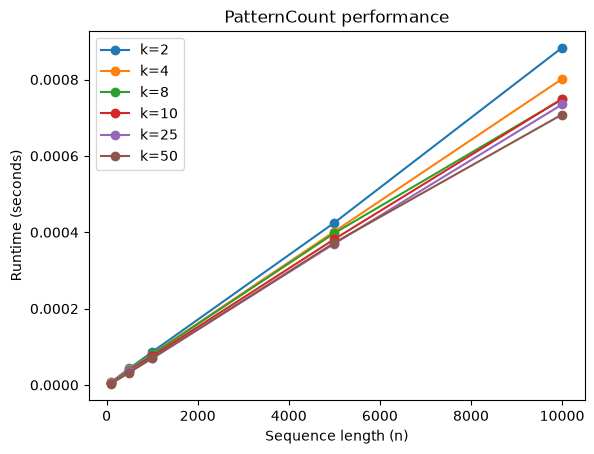

In [20]:
# Plot the results of your experiment
import matplotlib.pyplot as plt

for k in sorted({r["k"] for r in pattern_results}):
    subset = [r for r in pattern_results if r["k"] == k]

    plt.plot(
        [r["n"] for r in subset],
        [r["time"] for r in subset],
        marker="o",
        label=f"k={k}"
    )

plt.xlabel("Sequence length (n)")
plt.ylabel("Runtime (seconds)")
plt.title("PatternCount performance")
plt.legend()
plt.show()

In [21]:
def make_frequent_words_args(n, k):
    rng = random.Random(258 + n)
    text = "".join(rng.choices("ACGT", k=n))
    return text, k

fw_results = benchmark_grid(
    FrequentWords,
    make_frequent_words_args,
    ns=[50, 100, 200, 400, 800],
    ks=[2, 4, 6, 8, 10],
    repeats=3
)

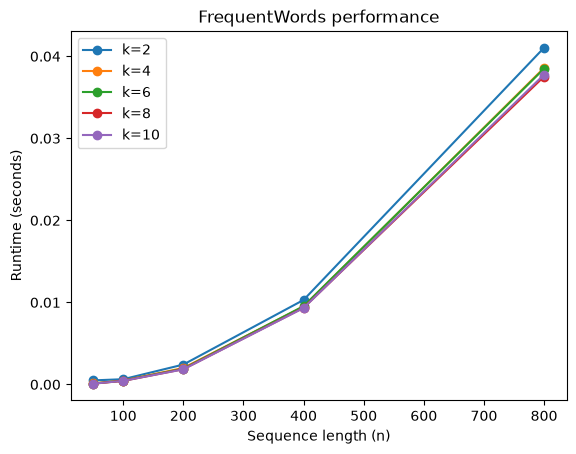

In [22]:
for k in sorted({r["k"] for r in fw_results}):
    subset = [r for r in fw_results if r["k"] == k]

    plt.plot(
        [r["n"] for r in subset],
        [r["time"] for r in subset],
        marker="o",
        label=f"k={k}"
    )

plt.xlabel("Sequence length (n)")
plt.ylabel("Runtime (seconds)")
plt.title("FrequentWords performance")
plt.legend()
plt.show()

Think through the following questions as you interpret your results:
- Holding *k* approximately constant, how does runtime change as *n* increases?
- Holding *n* approximately constant, what happens as *k* increases?
- How do the curves for PatternCount and FrequentWords differ?
- Are these patterns consistent with the computational complexity your group predicted in class? If not, what might explain the difference?